In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [3]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [4]:
tmp = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits', columns=['SV1_DESI_TARGET', 'TARGETS', 'coadd_type']))
mask = (tmp['SV1_DESI_TARGET'] & 2**0 > 0) & (tmp['TARGETS']=='QSO+LRG') & (tmp['coadd_type']!='pernight')
idx = np.where(mask)[0]
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits', rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

581288
52023


In [5]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

FIBERSTATUS 471632 109656 0.18864315107141383
No data 471629 3 6.360891542558605e-06


In [6]:
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

471629
43202


In [7]:
# # Remove duplicates
# _, idx = np.unique(zbest['TARGETID'], return_index=True)
# zbest = zbest[idx]
# print(len(zbest))
# print(len(np.unique(zbest['TARGETID'])))

__Add MEDIUM masks__

In [8]:
maskbits = [8, 9]

mask_clean = np.ones(len(zbest), dtype=bool)
for bit in maskbits:
    mask_clean &= (zbest['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))

zbest = zbest[mask_clean]

0.0392617926378573


__South only (for now)__

In [9]:
mask = zbest['PHOTSYS']=='S'
print(np.sum(mask)/len(mask))
zbest = zbest[mask]

0.5674910397429334


In [10]:
# # Ting-Wen's quality cuts
# mask = zbest['ZWARN']==0
# print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# mask &= zbest['Z']<1.4
# print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# mask &= zbest['DELTACHI2']>20
# print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# zbest = zbest[mask]
# print(len(zbest))

In [11]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']) - 3.214 * zbest['EBV']
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']) - 2.165 * zbest['EBV']
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']) - 1.211 * zbest['EBV']
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']) - 0.184 * zbest['EBV']
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']) - 0.113 * zbest['EBV']
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']) - 3.214 * zbest['EBV']
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']) - 2.165 * zbest['EBV']
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']) - 1.211 * zbest['EBV']

In [12]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

__New 600/sqdeg selection__

In [13]:
# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.6)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.14) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.23) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.29
lrg_mask &= lrg_mask_sliding

mask_lowz = ((gmag - rmag) > -1 * (rmag - w1mag)+2.9)  # low-z cut
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

lrg_new_south = lrg_mask.copy()
print(np.sum(lrg_new_south))

# lrg_new = lrg_new_south | lrg_new_north
lrg_new = lrg_new_south.copy()

70189


__Calculate the area based on total number of targets and area__

---------
## EFFTIME_DARK > 3000

In [15]:
# Depth cut
min_depth = 3000.
mask_depth = zbest['EFFTIME_DARK']>min_depth
mask_depth &= zbest['coadd_type']=='cumulative'
print('Min depth', np.sum(mask_depth), np.sum(~mask_depth), np.sum(mask_depth)/len(mask_depth))
print(len(zbest[mask_depth]), len(np.unique(zbest['TARGETID'][mask_depth])))

Min depth 15318 241819 0.05957135690312946
15318 15318


In [16]:
# numbers from another notebook
area_tot = 10109.0
n_lrg_new_tot = 6046903
density_tot = n_lrg_new_tot/area_tot
print(density_tot)

area_south = np.sum(lrg_new_south & mask_depth)/n_lrg_new_tot * area_tot
print(area_south)

area_north = 0
# area_north = np.sum(lrg_new_north & mask_depth)/n_lrg_new_tot * area_tot
# print(area_north)

area = area_north + area_south
print(area)

598.1702443367296
6.9929924458851085
6.9929924458851085


In [17]:
mask_star = (zbest['SPECTYPE']=='STAR') | (zbest['Z']<0.0003)
good_z = (zbest['DELTACHI2']>15) & (zbest['Z']<1.4)
mask_quality = good_z & (~mask_star)
print(np.sum(lrg_new & mask_depth & mask_quality)/np.sum(lrg_new & mask_depth))
print(np.sum(lrg_new & mask_depth & mask_quality)/area)

0.9863734162084629
590.0192273806709


[-0.1  0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2
  1.3  1.4]


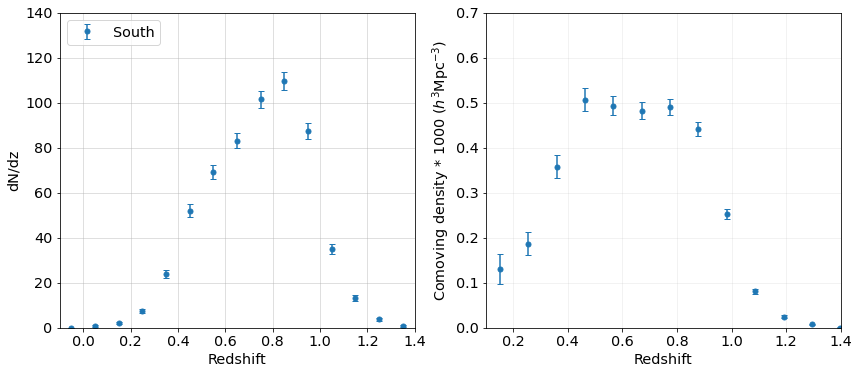

In [18]:
bins = np.arange(-0.1, 1.45, 0.1)
print(bins)
bin_centers = (bins[1:]+bins[:-1])/2

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    counts_south, _ = np.histogram(zbest['Z'][lrg_new_south & mask_depth & mask_quality], bins=bins)
    frac_err_south = 1/np.sqrt(counts_south)  # Poisson error only
    # counts_north, _ = np.histogram(zbest['Z'][lrg_new_north & mask_depth & mask_quality], bins=bins)
    # frac_err_north = 1/np.sqrt(counts_north)  # Poisson error only
    frac_err_south[~np.isfinite(frac_err_south)] = 0
    # frac_err_north[~np.isfinite(frac_err_north)] = 0
    
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].errorbar(bin_centers, counts_south/area_south, yerr=frac_err_south*counts_south/area_south, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='South')
# axes[0].errorbar(bin_centers, counts_north/area_north, yerr=frac_err_north*counts_north/area_north, fmt='o', ms=5, color='C1', capsize=3, capthick=1, label='North')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.4)
axes[0].set_ylim(0, 140)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_new_south & mask_depth & mask_quality], area=area_south, zmin=0.1, zmax=1.45, dz=0.1, axis=[0.1, 1.4, 0, 0.7], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=True)
# axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_new_north & mask_depth & mask_quality], area=area_north, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.9], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=True)
# plt.legend(loc='lower left')
plt.show()

In [38]:
bins = np.round(np.arange(0., 1.5, 0.1), 2)

# surface density
counts = np.histogram(zbest['Z'][lrg_new_south & mask_depth & mask_quality], bins=bins)[0]
surf_density = counts/area_south

t = Table()
t['zmin'] = bins[:-1]
t['zmax'] = bins[1:]
t['N_z_norm'] = surf_density/density_tot
t['N_z_norm'].format = '%.4f'
t['N_z'] = surf_density
t['N_z'].format = '%.1f'
# t['comoving_density'] = comov_density
# t.write('data/lrg_dndz_20210330.txt', format='ascii.commented_header', 
#        formats={'zmin':'%4.2f', 'zmax':'%4.2f', 'N_z_800':'%.10g', 'N_z_600':'%.10g'},
#        overwrite=True)
print(np.sum(t['N_z']))
t

576.4843140284493


zmin,zmax,N_z_norm,N_z
float64,float64,float64,float64
0.0,0.1,0.0000,0.0
0.1,0.2,0.0000,0.0
0.2,0.3,0.0166,9.9
0.3,0.4,0.0302,18.1
0.4,0.5,0.0740,44.3
0.5,0.6,0.1284,76.8
0.6,0.7,0.1480,88.6
0.7,0.8,0.1949,116.6
0.8,0.9,0.1480,88.6


In [20]:
print('Stars: {:.1f} ({:.2f}%)'.format(np.sum(mask_star & lrg_new & mask_depth)/np.sum(lrg_new & mask_depth)*density_tot, np.sum(mask_star & lrg_new & mask_depth)/np.sum(lrg_new & mask_depth)*100))
print('Bad z: {:.1f} ({:.2f}%)'.format(np.sum((~good_z) & lrg_new & mask_depth)/np.sum(lrg_new & mask_depth)*density_tot, np.sum((~good_z) & lrg_new & mask_depth)/np.sum(lrg_new & mask_depth)*100))

Stars: 3.4 (0.57%)
Bad z: 4.7 (0.79%)


---------
## 850 < EFFTIME_DARK < 950

In [21]:
# Depth cut
mask_depth = (zbest['EFFTIME_DARK']>850) & (zbest['EFFTIME_DARK']<950)
mask_depth &= zbest['coadd_type']=='perexp'
print('Min depth', np.sum(mask_depth), np.sum(~mask_depth), np.sum(mask_depth)/len(mask_depth))
print(len(zbest[mask_depth]), len(np.unique(zbest['TARGETID'][mask_depth])))

Min depth 15273 241864 0.059396352916927554
15273 8249


In [22]:
# numbers from another notebook
area_tot = 10109.0
n_lrg_new_tot = 6046903
density_tot = n_lrg_new_tot/area_tot
print(density_tot)

area_south = np.sum(lrg_new_south & mask_depth)/n_lrg_new_tot * area_tot
print(area_south)

area_north = 0
# area_north = np.sum(lrg_new_north & mask_depth)/n_lrg_new_tot * area_tot
# print(area_north)

area = area_north + area_south
print(area)

598.1702443367296
6.809098310325137
6.809098310325137


In [23]:
mask_star = (zbest['SPECTYPE']=='STAR') | (zbest['Z']<0.0003)
good_z = (zbest['DELTACHI2']>15) & (zbest['Z']<1.4)
mask_quality = good_z & (~mask_star)
print(np.sum(lrg_new & mask_depth & mask_quality)/np.sum(lrg_new & mask_depth))
print(np.sum(lrg_new & mask_depth & mask_quality)/area)

0.9614534740977166
575.1128595194288


[-0.1  0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2
  1.3  1.4]


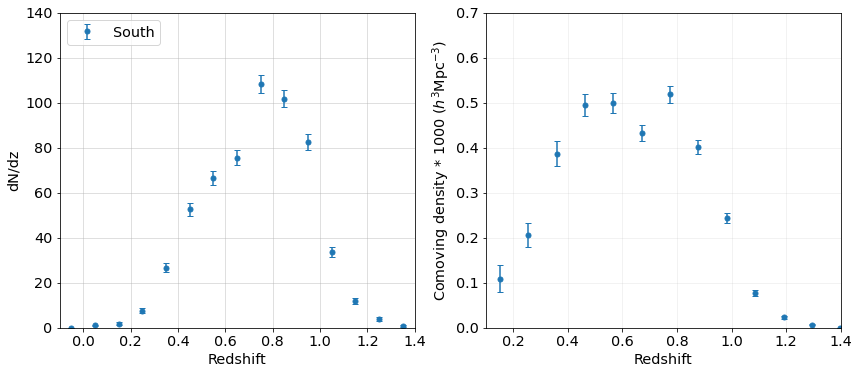

In [24]:
bins = np.arange(-0.1, 1.45, 0.1)
print(bins)
bin_centers = (bins[1:]+bins[:-1])/2

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    counts_south, _ = np.histogram(zbest['Z'][lrg_new_south & mask_depth & mask_quality], bins=bins)
    frac_err_south = 1/np.sqrt(counts_south)  # Poisson error only
    # counts_north, _ = np.histogram(zbest['Z'][lrg_new_north & mask_depth & mask_quality], bins=bins)
    # frac_err_north = 1/np.sqrt(counts_north)  # Poisson error only
    frac_err_south[~np.isfinite(frac_err_south)] = 0
    # frac_err_north[~np.isfinite(frac_err_north)] = 0
    
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].errorbar(bin_centers, counts_south/area_south, yerr=frac_err_south*counts_south/area_south, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='South')
# axes[0].errorbar(bin_centers, counts_north/area_north, yerr=frac_err_north*counts_north/area_north, fmt='o', ms=5, color='C1', capsize=3, capthick=1, label='North')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.4)
axes[0].set_ylim(0, 140)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_new_south & mask_depth & mask_quality], area=area_south, zmin=0.1, zmax=1.45, dz=0.1, axis=[0.1, 1.4, 0, 0.7], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=True)
# axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_new_north & mask_depth & mask_quality], area=area_north, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.9], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=True)
# plt.legend(loc='lower left')
plt.show()

[-0.1  0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2
  1.3  1.4]


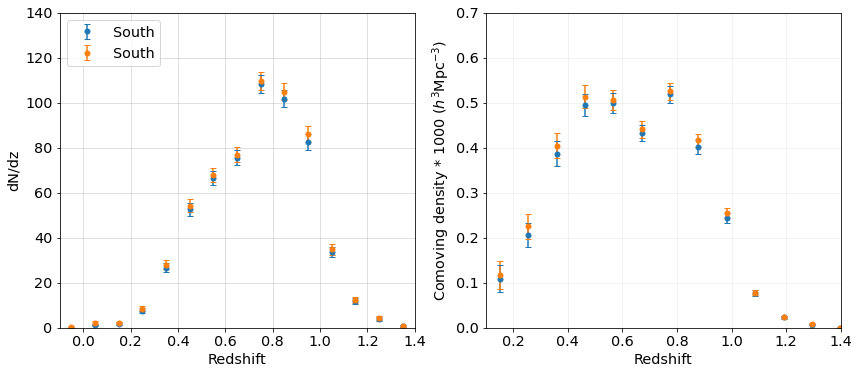

In [25]:
bins = np.arange(-0.1, 1.45, 0.1)
print(bins)
bin_centers = (bins[1:]+bins[:-1])/2

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    counts_south, _ = np.histogram(zbest['Z'][lrg_new_south & mask_depth & mask_quality], bins=bins)
    frac_err_south = 1/np.sqrt(counts_south)  # Poisson error only
    counts_south1, _ = np.histogram(zbest['Z'][lrg_new_south & mask_depth], bins=bins)
    frac_err_south1 = 1/np.sqrt(counts_south1)  # Poisson error only
    # counts_north, _ = np.histogram(zbest['Z'][lrg_new_north & mask_depth & mask_quality], bins=bins)
    # frac_err_north = 1/np.sqrt(counts_north)  # Poisson error only
    frac_err_south[~np.isfinite(frac_err_south)] = 0
    frac_err_south1[~np.isfinite(frac_err_south1)] = 0
    # frac_err_north[~np.isfinite(frac_err_north)] = 0
    
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].errorbar(bin_centers, counts_south/area_south, yerr=frac_err_south*counts_south/area_south, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='South')
axes[0].errorbar(bin_centers, counts_south1/area_south, yerr=frac_err_south1*counts_south1/area_south, fmt='o', ms=5, color='C1', capsize=3, capthick=1, label='South')
# axes[0].errorbar(bin_centers, counts_north/area_north, yerr=frac_err_north*counts_north/area_north, fmt='o', ms=5, color='C1', capsize=3, capthick=1, label='North')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.4)
axes[0].set_ylim(0, 140)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_new_south & mask_depth & mask_quality], area=area_south, zmin=0.1, zmax=1.45, dz=0.1, axis=[0.1, 1.4, 0, 0.7], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=True)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_new_south & mask_depth], area=area_south, zmin=0.1, zmax=1.45, dz=0.1, axis=[0.1, 1.4, 0, 0.7], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=True)
# axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_new_north & mask_depth & mask_quality], area=area_north, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.9], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=True)
# plt.legend(loc='lower left')
plt.show()

In [26]:
bins = np.round(np.arange(0.1, 1.5, 0.1), 2)

# surface density
counts = np.histogram(zbest['Z'][lrg_new_south & mask_depth & mask_quality], bins=bins)[0]
surf_density = np.round(counts/area_south, 1)

t = Table()
t['zmin'] = bins[:-1]
t['zmax'] = bins[1:]
t['N_z_norm'] = surf_density/density_tot
t['N_z_norm'].format = '%.4f'
t['N_z'] = surf_density
# t['comoving_density'] = comov_density
# t.write('data/lrg_dndz_20210330.txt', format='ascii.commented_header', 
#        formats={'zmin':'%4.2f', 'zmax':'%4.2f', 'N_z_800':'%.10g', 'N_z_600':'%.10g'},
#        overwrite=True)
print(np.sum(t['N_z']))
t

574.0999999999999


zmin,zmax,N_z_norm,N_z
float64,float64,float64,float64
0.1,0.2,0.0032,1.9
0.2,0.3,0.0127,7.6
0.3,0.4,0.0446,26.7
0.4,0.5,0.0879,52.6
0.5,0.6,0.1115,66.7
0.6,0.7,0.1262,75.5
0.7,0.8,0.1809,108.2
0.8,0.9,0.1702,101.8
0.9,1.0,0.1378,82.4


In [27]:
print('Stars: {:.1f} ({:.2f}%)'.format(np.sum(mask_star & lrg_new & mask_depth)/np.sum(lrg_new & mask_depth)*density_tot, np.sum(mask_star & lrg_new & mask_depth)/np.sum(lrg_new & mask_depth)*100))
print('Bad z: {:.1f} ({:.2f}%)'.format(np.sum((~good_z) & lrg_new & mask_depth)/np.sum(lrg_new & mask_depth)*density_tot, np.sum((~good_z) & lrg_new & mask_depth)/np.sum(lrg_new & mask_depth)*100))

Stars: 1.8 (0.29%)
Bad z: 21.3 (3.56%)


---------
## 950 < EFFTIME_DARK < 1050

In [28]:
# Depth cut
mask_depth = (zbest['EFFTIME_DARK']>950) & (zbest['EFFTIME_DARK']<1050)
mask_depth &= zbest['coadd_type']=='perexp'
print('Min depth', np.sum(mask_depth), np.sum(~mask_depth), np.sum(mask_depth)/len(mask_depth))
print(len(zbest[mask_depth]), len(np.unique(zbest['TARGETID'][mask_depth])))

Min depth 2372 254765 0.009224654561576125
2372 2372


In [29]:
# numbers from another notebook
area_tot = 10109.0
n_lrg_new_tot = 6046903
density_tot = n_lrg_new_tot/area_tot
print(density_tot)

area_south = np.sum(lrg_new_south & mask_depth)/n_lrg_new_tot * area_tot
print(area_south)

area_north = 0
# area_north = np.sum(lrg_new_north & mask_depth)/n_lrg_new_tot * area_tot
# print(area_north)

area = area_north + area_south
print(area)

598.1702443367296
1.1067083430972846
1.1067083430972846


In [30]:
mask_star = (zbest['SPECTYPE']=='STAR') | (zbest['Z']<0.0003)
good_z = (zbest['DELTACHI2']>15) & (zbest['Z']<1.4)
mask_quality = good_z & (~mask_star)
print(np.sum(lrg_new & mask_depth & mask_quality)/np.sum(lrg_new & mask_depth))
print(np.sum(lrg_new & mask_depth & mask_quality)/area)

0.9637462235649547
576.4843140284495


[-0.1  0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2
  1.3  1.4]


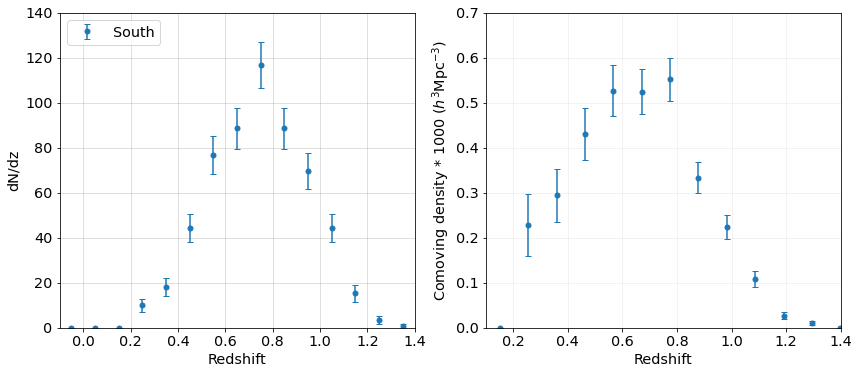

In [31]:
bins = np.arange(-0.1, 1.45, 0.1)
print(bins)
bin_centers = (bins[1:]+bins[:-1])/2

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    counts_south, _ = np.histogram(zbest['Z'][lrg_new_south & mask_depth & mask_quality], bins=bins)
    frac_err_south = 1/np.sqrt(counts_south)  # Poisson error only
    # counts_north, _ = np.histogram(zbest['Z'][lrg_new_north & mask_depth & mask_quality], bins=bins)
    # frac_err_north = 1/np.sqrt(counts_north)  # Poisson error only
    frac_err_south[~np.isfinite(frac_err_south)] = 0
    # frac_err_north[~np.isfinite(frac_err_north)] = 0
    
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].errorbar(bin_centers, counts_south/area_south, yerr=frac_err_south*counts_south/area_south, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='South')
# axes[0].errorbar(bin_centers, counts_north/area_north, yerr=frac_err_north*counts_north/area_north, fmt='o', ms=5, color='C1', capsize=3, capthick=1, label='North')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.4)
axes[0].set_ylim(0, 140)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_new_south & mask_depth & mask_quality], area=area_south, zmin=0.1, zmax=1.45, dz=0.1, axis=[0.1, 1.4, 0, 0.7], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=True)
# axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_new_north & mask_depth & mask_quality], area=area_north, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.9], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=True)
# plt.legend(loc='lower left')
plt.show()

In [33]:
bins = np.round(np.arange(0.1, 1.5, 0.1), 2)

# surface density
counts = np.histogram(zbest['Z'][lrg_new_south & mask_depth & mask_quality], bins=bins)[0]
surf_density = np.round(counts/area_south, 1)

t = Table()
t['zmin'] = bins[:-1]
t['zmax'] = bins[1:]
t['N_z_norm'] = surf_density/density_tot
t['N_z_norm'].format = '%.4f'
t['N_z'] = surf_density
# t['comoving_density'] = comov_density
# t.write('data/lrg_dndz_20210330.txt', format='ascii.commented_header', 
#        formats={'zmin':'%4.2f', 'zmax':'%4.2f', 'N_z_800':'%.10g', 'N_z_600':'%.10g'},
#        overwrite=True)
print(np.sum(t['N_z']))
t

576.6999999999999


zmin,zmax,N_z_norm,N_z
float64,float64,float64,float64
0.1,0.2,0.0000,0.0
0.2,0.3,0.0166,9.9
0.3,0.4,0.0303,18.1
0.4,0.5,0.0741,44.3
0.5,0.6,0.1284,76.8
0.6,0.7,0.1481,88.6
0.7,0.8,0.1949,116.6
0.8,0.9,0.1481,88.6
0.9,1.0,0.1164,69.6


In [34]:
print('Stars: {:.1f} ({:.2f}%)'.format(np.sum(mask_star & lrg_new & mask_depth)/np.sum(lrg_new & mask_depth)*density_tot, np.sum(mask_star & lrg_new & mask_depth)/np.sum(lrg_new & mask_depth)*100))
print('Bad z: {:.1f} ({:.2f}%)'.format(np.sum((~good_z) & lrg_new & mask_depth)/np.sum(lrg_new & mask_depth)*density_tot, np.sum((~good_z) & lrg_new & mask_depth)/np.sum(lrg_new & mask_depth)*100))

Stars: 5.4 (0.91%)
Bad z: 17.2 (2.87%)
